In [ ]:
using CoolProp, Printf
using Statistics, DataFrames, GLM, StatsModels, Plots

In [ ]:
# Plot Data to get an overview of the heat capacity of CO2
for (p, T) in [(250e5, 283.15), (150e5, 288.15), (100e5, 278.15)]
    ρ  = PropsSI("D", "P", p, "T", T, "CO2")
    β  = PropsSI("ISOBARIC_EXPANSION_COEFFICIENT", "P", p, "T", T, "CO2")
    κ  = PropsSI("ISOTHERMAL_COMPRESSIBILITY",     "P", p, "T", T, "CO2")
    cp = PropsSI("C", "P", p, "T", T, "CO2")
    cv = PropsSI("O", "P", p, "T", T, "CO2")

    mayer = T*β^2/(ρ*κ)
    @printf("%3.0f bar %6.2f K | ρ=%6.1f  βT=%.3f  κT=%.3e /bar  cp=%6.1f  cv=%6.1f  Mayer ratio=%.4f\n",
            p/1e5, T, ρ, β*T, κ*1e5, cp, cv, (cp - cv)/mayer)
end

250 bar 283.15 K | ρ=1001.7  βT=1.065  κT=3.954e-04 /bar  cp=1936.0  cv= 923.9  Mayer ratio=1.0000
150 bar 288.15 K | ρ= 929.8  βT=1.554  κT=7.142e-04 /bar  cp=2183.9  cv= 921.5  Mayer ratio=1.0000
100 bar 278.15 K | ρ= 948.3  βT=1.568  κT=7.042e-04 /bar  cp=2249.4  cv= 926.3  Mayer ratio=1.0000


In [50]:
# Pressure (Pa) and temperature (K) ranges
P_vals = collect(100e5:0.5e5:300e5)
T_vals = collect(273:1:293)

# 2D matrix: rows = P_vals, columns = T_vals
cv = [PropsSI("O", "T", T, "P", P, "CO2") for P in P_vals, T in T_vals] # Isobaric expansion coefficient in 1/K

# Example: isobaric_expansion_coefficient_vals[i, j] corresponds to P_vals[i], T_vals[j]
# vec() flattens column-major, so P must vary fastest (outer) and T slowest (inner)
df = DataFrame(
    P = repeat(P_vals, outer=length(T_vals)),
    T = repeat(T_vals, inner=length(P_vals)),
    y = vec(cv)
)

Row,P,T,y
,Float64,Int64,Float64
1,1.0e7,273,927.251
2,1.005e7,273,927.234
3,1.01e7,273,927.217
4,1.015e7,273,927.201
5,1.02e7,273,927.186
6,1.025e7,273,927.171
7,1.03e7,273,927.157
8,1.035e7,273,927.143
9,1.04e7,273,927.129


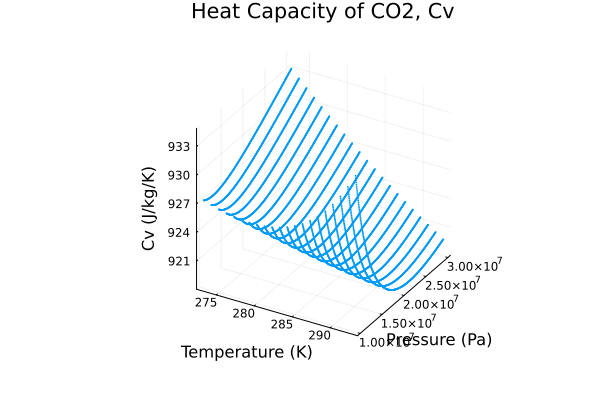

In [55]:
# Raw data plot as a 3D scatter: each point is one (T, P, y) sample
T_grid = repeat(T_vals, inner=length(P_vals))
P_grid = repeat(P_vals, outer=length(T_vals))

scatter(
    T_grid,
    P_grid,
    vec(cv),
    xlabel = "Temperature (K)",
    ylabel = "Pressure (Pa)",
    zlabel = "Cv (J/kg/K)",
    title = "Heat Capacity of CO2, Cv" ,
    markersize = 1,
    markerstrokewidth = 0,
    legend = false
 )